In [1]:
import torch 
import numpy as np

In [4]:
# the pytoch neural network module (torch.nn)

# building the linear regression model 

X_train = np.arange(10 , dtype = 'float32').reshape(10 ,1)
y_train = np.array([1.0 , 1.3 , 3.1 , 2.0 , 5.0 , 6.3 , 6.6 ,7.4 , 8.0, 9.0], dtype ='float32')

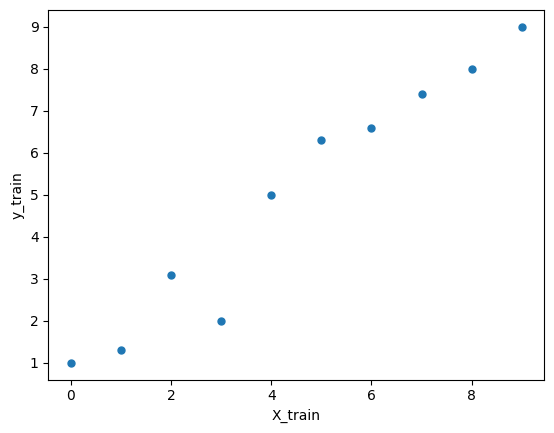

In [31]:
import matplotlib.pyplot as plt 

plt.plot(X_train , y_train , 'o', markersize = 5)
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.show()

## Normalizing the Data 
**3 modes of the normalization**

simple feature scaling Xnew = Xold/Xmax

min max scaling = Xnew --> (Xold - Xmin) / Xmax - Xmin

z score = Xold - mean/ stdev   `this is the **Standard sclaler**`

In [8]:
from torch.utils.data import TensorDataset 

In [17]:
# standarize the data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sk = scaler.fit_transform(X_train)
X_train_sk = torch.from_numpy(X_train_sk)

## second method 
X_train_norm = (X_train - np.mean(X_train)/ np.std(X_train))
X_train_norm = torch.from_numpy(X_train_norm)

y_train_sk = torch.from_numpy(y_train)

batch_size = 1

# creating the dataset 
train_ds = TensorDataset(X_train_sk , y_train_sk)

from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds , batch_size, shuffle=True)

for i in train_dl:
    print(i)

[tensor([[-0.1741]]), tensor([5.])]
[tensor([[0.5222]]), tensor([6.6000])]
[tensor([[1.5667]]), tensor([9.])]
[tensor([[-0.5222]]), tensor([2.])]
[tensor([[0.8704]]), tensor([7.4000])]
[tensor([[0.1741]]), tensor([6.3000])]
[tensor([[-0.8704]]), tensor([3.1000])]
[tensor([[-1.5667]]), tensor([1.])]
[tensor([[-1.2185]]), tensor([1.3000])]
[tensor([[1.2185]]), tensor([8.])]


In [18]:
# defining the Linear Regression Problem from start 

torch.manual_seed(42)

weight = torch.randn(1) # generate the random number 

weight. requires_grad_()
bias = torch.zeros(1, requires_grad = True)

def model(x):
    return x @ weight+ bias 



In [19]:
def loss_fn(input , target):
    return (input - target).pow(2).mean()   # MSE meansquareerror


In [20]:

from tqdm import tqdm

In [29]:
lr = 0.001
num_epochs = 200
log_epochs = 10

pbar = tqdm(range(num_epochs))
for e in pbar:
        
    for x_batch , y_batch in train_dl:
            pred = model(x_batch)
            
            loss = loss_fn(pred , y_batch)
            loss.backward()
    with torch.no_grad():
            weight -= weight.grad * lr 
            bias -= bias.grad * lr 
            
            weight.grad.zero_()
            bias.grad.zero_()
            
    pbar.set_postfix(loss=f"{loss.item():.4f}")

100%|██████████| 200/200 [00:00<00:00, 258.64it/s, loss=0.0468]


In [30]:
# let's loook at the train model and plot it 

print(f'Final Parameters , Weights --> {weight.item()} Bias --> {bias.item()}')

Final Parameters , Weights --> 2.706913471221924 Bias --> 4.9700117111206055


In [32]:
# Creatng the test dataset
X_test = np.linspace(0,9 , num=100 , dtype = 'float32').reshape(-1,1)

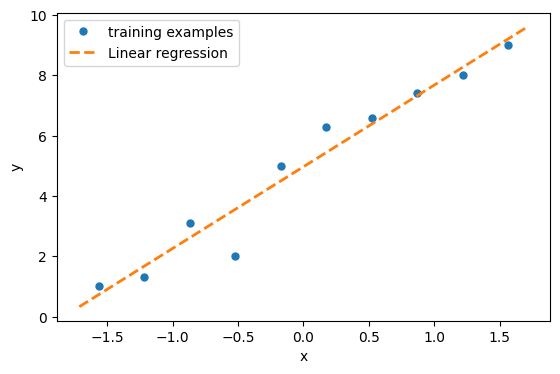

In [45]:
# normalizing the test dataset 
scaler = StandardScaler()
X_test_sk = scaler.fit_transform(X_test)
X_test_sk = torch.from_numpy(X_test_sk)


ypred = model(X_test_sk).detach().numpy()


# plotting the data

fig = plt.figure(figsize = (14,4))
ax = fig.add_subplot(1,2,1)

plt.plot(X_train_sk , y_train_sk , 'o' , markersize= 5)
plt.plot(X_test_sk , ypred , '--' , lw = 2)

plt.legend(['training examples' , 'Linear regression'] , fontsize = 10)
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()
